# Regressão Logística e Regularização

## Regressão Logística

### Motivação

A regressão linear prevê valores contínuos. Quando o objetivo é **classificar** uma amostra em duas categorias (spam/não-spam, fraude/legítimo, doente/saudável), precisamos de um modelo que produza uma **probabilidade** — um valor em $[0, 1]$.

A regressão logística resolve isso aplicando a função sigmoide à saída linear:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w}^\top \mathbf{x} + b$$


### Função Sigmoide

A sigmoide mapeia qualquer valor real para $(0, 1)$:

| $z$ | $\sigma(z)$ |
|-----|-------------|
| $-\infty$ | $\to 0$ |
| $0$ | $0.5$ |
| $+\infty$ | $\to 1$ |

**Propriedades importantes:**
- $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — derivada elegante, útil no backprop
- Simétrica em torno de $z = 0$
- Saturação nas extremidades → problema do *vanishing gradient* em redes profundas


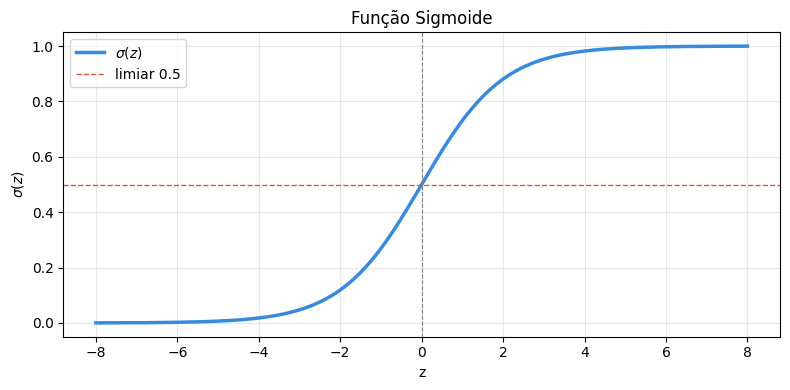

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), color='#378ADD', lw=2.5, label=r'$\sigma(z)$')
plt.axhline(0.5, color='#D85A30', lw=1, ls='--', label='limiar 0.5')
plt.axvline(0,   color='gray',    lw=0.8, ls='--')
plt.xlabel('z'); plt.ylabel(r'$\sigma(z)$')
plt.title('Função Sigmoide'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Regra de Decisão

$$\hat{y} \geq 0.5 \;\Rightarrow\; \text{classe } 1 \quad (\text{equivalente a } z \geq 0)$$
$$\hat{y} < 0.5 \;\Rightarrow\; \text{classe } 0 \quad (\text{equivalente a } z < 0)$$

A **fronteira de decisão** é o hiperplano $\mathbf{w}^\top \mathbf{x} + b = 0$.


### Função de Custo: Binary Cross-Entropy (Log-Loss)


#### Por que não usar MSE?

Com a sigmoide, o MSE $J = \frac{1}{m}\sum(\hat{y} - y)^2$ gera uma superfície **não-convexa** — cheia de mínimos locais. O gradiente descendente não converge de forma confiável.


#### Log-Loss

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

**Intuição por caso:**

| Rótulo verdadeiro | Custo | Comportamento |
|---|---|---|
| $y = 1$ | $-\log(\hat{y})$ | Penaliza fortemente quando $\hat{y} \to 0$ |
| $y = 0$ | $-\log(1 - \hat{y})$ | Penaliza fortemente quando $\hat{y} \to 1$ |

A log-loss é **convexa** para regressão logística → garantia de convergência ao mínimo global.


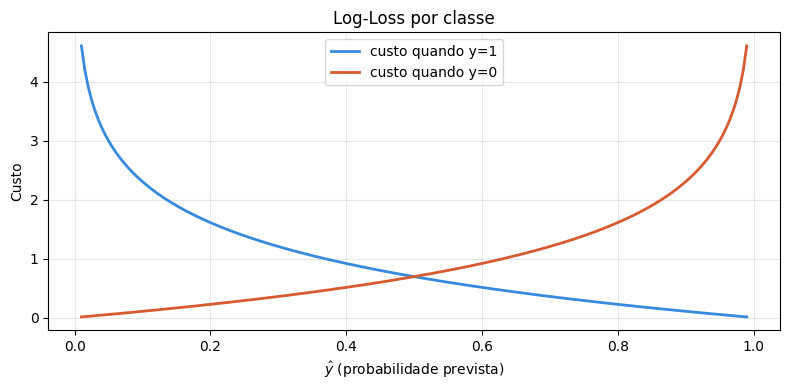

In [ ]:
def log_loss(y_true, y_pred):
    eps = 1e-9  # evita log(0)
    return -np.mean(y_true * np.log(y_pred + eps) +
                    (1 - y_true) * np.log(1 - y_pred + eps))

# Visualizando o custo para y=1 e y=0
p = np.linspace(0.01, 0.99, 200)
plt.figure(figsize=(8, 4))
plt.plot(p, -np.log(p),     color='#378ADD', lw=2, label='custo quando y=1')
plt.plot(p, -np.log(1 - p), color='#D85A30', lw=2, label='custo quando y=0')
plt.xlabel(r'$\hat{y}$ (probabilidade prevista)')
plt.ylabel('Custo'); plt.title('Log-Loss por classe')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Gradiente Descendente

### Ideia Central

Minimizar $J(\mathbf{w}, b)$ iterativamente movendo os parâmetros na **direção oposta ao gradiente**:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \frac{\partial J}{\partial \mathbf{w}}$$
$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

onde $\alpha > 0$ é o **learning rate** (taxa de aprendizado).

### Gradientes da Log-Loss para Regressão Logística

Uma propriedade notável: os gradientes têm forma linear simples.

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y})$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

> **Observação:** O resíduo $(\hat{y} - y)$ é a diferença entre previsão e rótulo — mesma forma do gradiente do MSE, mas aqui derivado da log-loss com a sigmoide.

### Algoritmo Completo

```
Inicializar w = 0, b = 0
Para cada época t = 1, 2, ..., T:
    1. Forward:  ŷ = σ(Xw + b)
    2. Custo:    J = log_loss(y, ŷ)
    3. Backward: dw = (1/m) * X^T (ŷ - y)
                 db = (1/m) * sum(ŷ - y)
    4. Update:   w ← w - α * dw
                 b ← b - α * db
```

### Implementação

#### Setup — dataset de referência

Usaremos o **Breast Cancer Wisconsin** (disponível nativamente no scikit-learn): 569 amostras, 30 features numéricas, binário — `0` = maligno, `1` = benigno. É o dataset padrão para exemplos de classificação binária com regressão logística.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)

# Carrega dataset
data = load_breast_cancer()
X, y = data.data, data.target          # y: 0=maligno, 1=benigno
feature_names = data.feature_names

print(f"Amostras   : {X.shape[0]}")
print(f"Features   : {X.shape[1]}")
print(f"Classes    : {data.target_names}  →  {np.bincount(y)}")

# Split treino/teste — definido aqui, reutilizado em todas as seções
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTreino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Amostras   : 569
Features   : 30
Classes    : ['malignant' 'benign']  →  [212 357]

Treino: 455 amostras | Teste: 114 amostras


#### Opção A — `LogisticRegression` (solver L-BFGS / liblinear)

O estimador padrão do scikit-learn usa solvers L-BFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno) de segunda ordem (quasi-Newton) — mais eficientes que o GD puro para datasets de tamanho moderado.


In [ ]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)

print(f"Acurácia : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:,1]):.4f}")
print(classification_report(y_test, y_pred, target_names=data.target_names))

modelo = pipe_lr.named_steps['model']
print(f"Intercepto   : {modelo.intercept_[0]:.4f}")

Acurácia : 0.9825
AUC-ROC  : 0.9954
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Intercepto   : 0.3022


#### Opção B — `SGDClassifier` (gradiente descendente estocástico)

Equivalente ao nosso algoritmo manual — usa log-loss com mini-batch SGD, com suporte a early stopping, learning rate adaptativo e regularização integrada.


In [ ]:
pipe_sgd = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SGDClassifier(
                   loss='log_loss',          # log-loss = binary cross-entropy
                   learning_rate='optimal',  # α_t = 1/(α·(t + t₀)), heurística de Léon Bottou
                   max_iter=1000,
                   tol=1e-4,
                   early_stopping=True,
                   validation_fraction=0.1,
                   n_iter_no_change=10,
                   random_state=42))
])

pipe_sgd.fit(X_train, y_train)
y_pred_sgd = pipe_sgd.predict(X_test)

print(f"Acurácia (SGD): {accuracy_score(y_test, y_pred_sgd):.4f}")
print(f"AUC-ROC  (SGD): {roc_auc_score(y_test, pipe_sgd.predict_proba(X_test)[:,1]):.4f}")

Acurácia (SGD): 0.9825
AUC-ROC  (SGD): 0.9944


#### Comparando as duas abordagens

In [ ]:
modelos = {
    'LogisticRegression (L-BFGS)': pipe_lr,
    'SGDClassifier (log-loss)':    pipe_sgd,
}

print(f"{'Modelo':<35} {'Acurácia':>10}")
print("-" * 47)
for nome, pipe in modelos.items():
    acc = accuracy_score(y_test, pipe.predict(X_test))
    print(f"{nome:<35} {acc:>10.4f}")


Modelo                                Acurácia
-----------------------------------------------
LogisticRegression (L-BFGS)             0.9825
SGDClassifier (log-loss)                0.9825


| Aspecto | `LogisticRegression` | `SGDClassifier` |
|---|---|---|
| **Algoritmo interno** | L-BFGS / liblinear / saga | Mini-batch SGD |
| **Complexidade** | $O(mn \cdot k)$, $k$ iterações | $O(mn \cdot T)$ |
| **Escalabilidade** | Moderada | Excelente (online learning) |
| **Regularização** | L1, L2, ElasticNet (`penalty=`) | L1, L2, ElasticNet (`penalty=`) |
| **Probabilidades** | `predict_proba` calibradas | `predict_proba` via Platt scaling |
| **Quando usar** | Datasets até ~10⁵ amostras | Datasets grandes, streaming |


### Avaliação e Visualização do Modelo

Continuamos usando `X_train`, `X_test`, `y_train`, `y_test` e `pipe_lr` definidos na célula anterior.


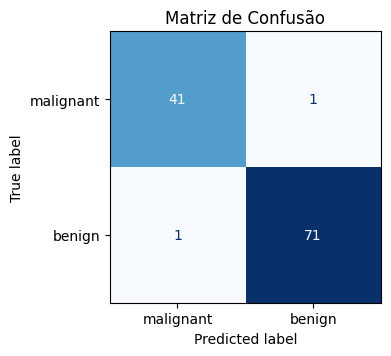

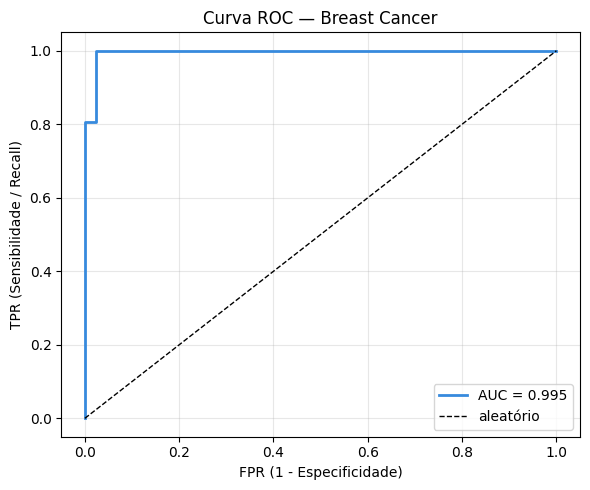

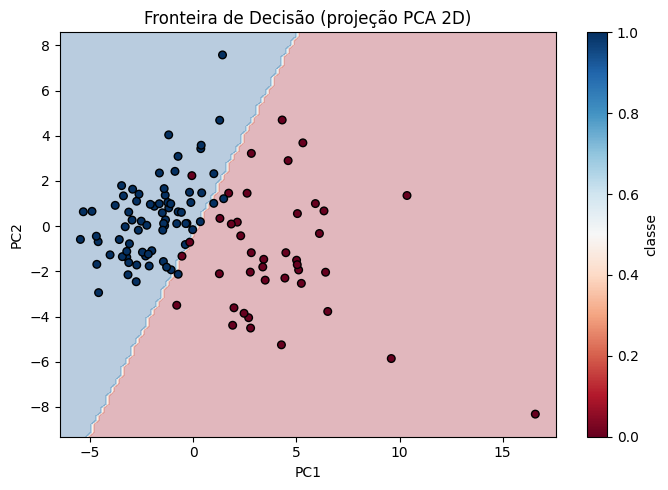

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA

# --- Matriz de confusão ---
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_estimator(
    pipe_lr, X_test, y_test, ax=ax,
    display_labels=data.target_names,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão'); plt.tight_layout(); plt.show()

# --- Curva ROC ---
y_proba = pipe_lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], 'k--', lw=1, label='aleatório')
plt.xlabel('FPR (1 - Especificidade)')
plt.ylabel('TPR (Sensibilidade / Recall)')
plt.title('Curva ROC — Breast Cancer')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# --- Fronteira de decisão em 2D (projeção PCA) ---
# Com 30 features, usamos PCA p/ reduzir a 2 componentes apenas para visualização
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(pipe_lr.named_steps['scaler'].transform(X_train))
X_test_2d  = pca.transform(pipe_lr.named_steps['scaler'].transform(X_test))

pipe_2d = Pipeline([('model', LogisticRegression(max_iter=1000, random_state=42))])
pipe_2d.fit(X_train_2d, y_train)

fig, ax = plt.subplots(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    pipe_2d, X_test_2d, alpha=0.3, ax=ax,
    response_method='predict', cmap='RdBu')
scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                     c=y_test, edgecolors='k', cmap='RdBu', s=30)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Fronteira de Decisão (projeção PCA 2D)')
plt.colorbar(scatter, ax=ax, label='classe')
plt.tight_layout(); plt.show()

### Impacto do Learning Rate

Com `SGDClassifier` e `warm_start=True` simulamos época a época e observamos a evolução da log-loss. Usamos o scaler já ajustado no treino do Breast Cancer:


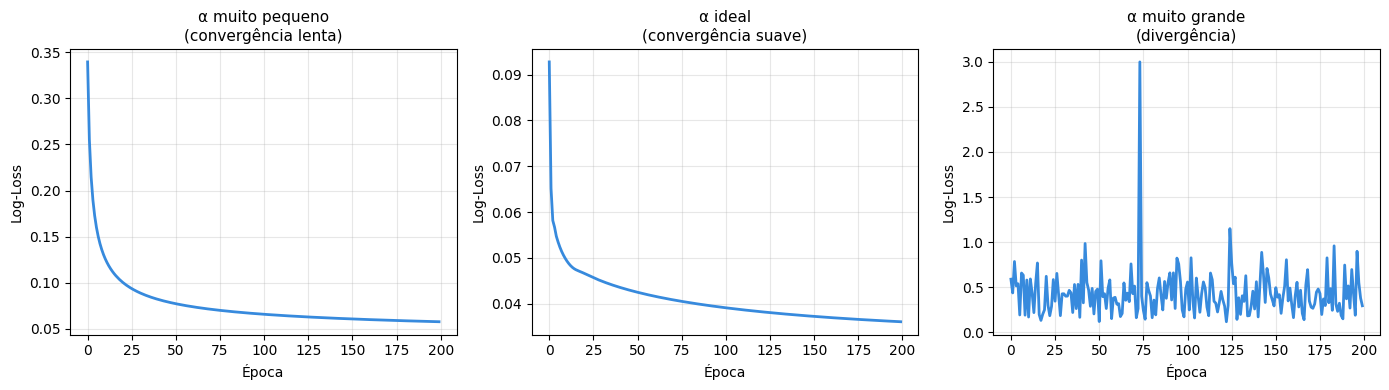

In [ ]:
from sklearn.metrics import log_loss

# Normalização manual para alimentar o SGD diretamente (sem Pipeline)
scaler_fit = StandardScaler().fit(X_train)
X_tr_n = scaler_fit.transform(X_train)
X_te_n = scaler_fit.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    (0.001, 'α muito pequeno\n(convergência lenta)'),
    (0.1,   'α ideal\n(convergência suave)'),
    (2.0,   'α muito grande\n(divergência)'),
]

for ax, (eta, title) in zip(axes, configs):
    losses = []
    sgd = SGDClassifier(loss='log_loss', learning_rate='constant',
                        eta0=eta, max_iter=1, warm_start=True,
                        tol=None, random_state=42)
    for _ in range(200):
        sgd.fit(X_tr_n, y_train)
        proba = sgd.predict_proba(X_tr_n)
        losses.append(log_loss(y_train, proba))

    ax.plot(np.clip(losses, 0, 3), lw=2, color='#378ADD')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Época'); ax.set_ylabel('Log-Loss')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Variantes do Gradiente Descendente

| Variante | Amostras por passo | Prós | Contras |
|---|---|---|---|
| **Batch GD** | Todos os $m$ | Gradiente exato, convergência suave | Lento para $m$ grande |
| **SGD** | 1 | Rápido, pode escapar de mínimos locais | Ruidoso, oscila |
| **Mini-batch GD** | $k \in [32, 512]$ | Balanço velocidade/estabilidade | Hiperparâmetro extra |
| **Adam** | Mini-batch | Adapta $\alpha$ por parâmetro, momento | Mais complexo |

> Na prática, **mini-batch GD** é o padrão. Adam é o default para redes neurais.


## Regularização: Ridge e Lasso


### Problema: Overfitting

Um modelo com muitos parâmetros ou treinado por muitas épocas pode **memorizar** os dados de treino, perdendo capacidade de generalização.

**Sintomas:**
- Custo de treino baixo, custo de validação alto
- Pesos $\mathbf{w}$ com magnitudes muito grandes


### Solução: Adicionar Penalidade ao Custo

A regularização adiciona um termo que penaliza pesos grandes:

$$J_{\text{reg}}(\mathbf{w}, b) = J(\mathbf{w}, b) + \text{penalidade}(\mathbf{w})$$

> O bias $b$ **não** é regularizado — ele controla apenas o deslocamento global.


### Lasso — Regularização L1

$$J_{\text{Lasso}} = J(\mathbf{w}, b) + \frac{\lambda}{m} \sum_{j=1}^{n} |w_j|$$

**Gradiente (subgradiente em $w_j = 0$):**

$$\frac{\partial J_{\text{Lasso}}}{\partial w_j} = \frac{1}{m}\sum_i x_j^{(i)}(\hat{y}^{(i)} - y^{(i)}) + \frac{\lambda}{m}\text{sign}(w_j)$$

**Propriedades:**
- Produz soluções **esparsas**: coeficientes podem ser exatamente zero
- Funciona como **seleção automática de features**
- Sem solução fechada (não-diferenciável em $w_j = 0$)
- Algoritmos: ISTA, coordinate descent, ADMM
- Região de restrição geométrica: **losango** (diamond em 2D)

> **Intuição geométrica:** as curvas de nível da loss tocam o losango L1 nos **vértices** (onde algum $w_j = 0$), mas tocam a bola L2 em pontos genéricos (sem zerar coeficientes).


### Ridge — Regularização L2

$$J_{\text{Ridge}} = J(\mathbf{w}, b) + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

**Gradiente modificado:**

$$\frac{\partial J_{\text{Ridge}}}{\partial \mathbf{w}} = \frac{1}{m}\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y}) + \frac{\lambda}{m}\mathbf{w}$$

**Atualização:**

$$\mathbf{w} \leftarrow \mathbf{w}\left(1 - \frac{\alpha\lambda}{m}\right) - \alpha \cdot \frac{1}{m}\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$$

O fator $\left(1 - \frac{\alpha\lambda}{m}\right) < 1$ **comprime** os pesos a cada passo — por isso L2 também é chamada de *weight decay*.

**Propriedades:**
- Solução fechada: $\mathbf{w}^* = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$
- Pesos comprimidos em direção a zero, mas **nunca exatamente zero**
- Distribui o efeito entre features correlacionadas
- Região de restrição geométrica: **bola** (circular em 2D)


### Escolhendo λ com Validação Cruzada


Melhor C (Ridge): 0.7880  →  λ ≈ 1.2690
Melhor C (Lasso): 1.2690  →  λ ≈ 0.7880


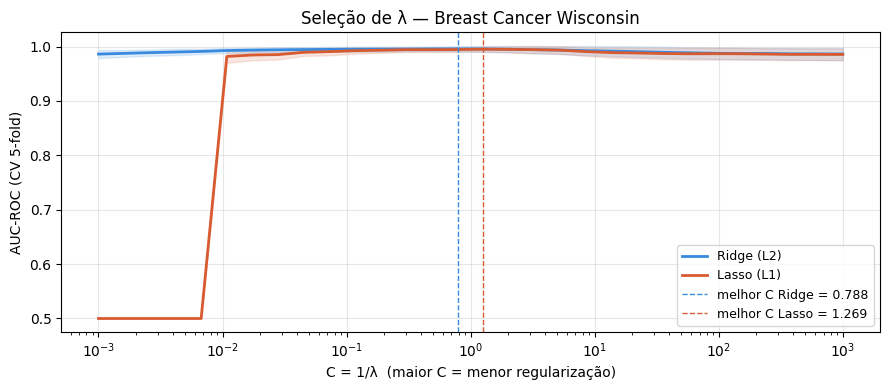

Ridge   C=0.7880  AUC=0.9957  Acc=0.9825  coef≈0: 0/30
Lasso   C=1.2690  AUC=0.9964  Acc=0.9912  coef≈0: 11/30


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# sklearn usa C = 1/λ — quanto menor C, maior a regularização
Cs = np.logspace(-3, 3, 30)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ridge_means, ridge_stds = [], []
lasso_means, lasso_stds = [], []

for C in Cs:
    pipe_r = Pipeline([('scaler', StandardScaler()),
                       ('model',  LogisticRegression(C=C, penalty='l2',
                                                     solver='lbfgs',
                                                     max_iter=1000))])
    pipe_l = Pipeline([('scaler', StandardScaler()),
                       ('model',  LogisticRegression(C=C, penalty='l1',
                                                     solver='liblinear',
                                                     max_iter=1000))])

    s_r = cross_val_score(pipe_r, X_train, y_train, cv=cv, scoring='roc_auc')
    s_l = cross_val_score(pipe_l, X_train, y_train, cv=cv, scoring='roc_auc')

    ridge_means.append(s_r.mean()); ridge_stds.append(s_r.std())
    lasso_means.append(s_l.mean()); lasso_stds.append(s_l.std())

ridge_means, ridge_stds = np.array(ridge_means), np.array(ridge_stds)
lasso_means, lasso_stds = np.array(lasso_means), np.array(lasso_stds)

# Melhor C para cada penalidade
best_C_ridge = Cs[np.argmax(ridge_means)]
best_C_lasso = Cs[np.argmax(lasso_means)]
print(f"Melhor C (Ridge): {best_C_ridge:.4f}  →  λ ≈ {1/best_C_ridge:.4f}")
print(f"Melhor C (Lasso): {best_C_lasso:.4f}  →  λ ≈ {1/best_C_lasso:.4f}")

# Curva AUC-ROC média ± desvio por C
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(Cs, ridge_means, color='#378ADD', lw=2, label='Ridge (L2)')
ax.fill_between(Cs, ridge_means - ridge_stds, ridge_means + ridge_stds,
                alpha=0.15, color='#378ADD')

ax.plot(Cs, lasso_means, color='#D85A30', lw=2, label='Lasso (L1)')
ax.fill_between(Cs, lasso_means - lasso_stds, lasso_means + lasso_stds,
                alpha=0.15, color='#D85A30')

ax.axvline(best_C_ridge, color='#378ADD', lw=1, ls='--',
           label=f'melhor C Ridge = {best_C_ridge:.3f}')
ax.axvline(best_C_lasso, color='#D85A30', lw=1, ls='--',
           label=f'melhor C Lasso = {best_C_lasso:.3f}')

ax.set_xscale('log')
ax.set_xlabel('C = 1/λ  (maior C = menor regularização)')
ax.set_ylabel('AUC-ROC (CV 5-fold)')
ax.set_title('Seleção de λ — Breast Cancer Wisconsin')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Avaliação final no teste com o melhor C de cada penalidade
for nome, C, penalty, solver in [
        ('Ridge', best_C_ridge, 'l2', 'lbfgs'),
        ('Lasso', best_C_lasso, 'l1', 'liblinear')]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model',  LogisticRegression(C=C, penalty=penalty,
                                                   solver=solver, max_iter=1000))])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    acc = accuracy_score(y_test, pipe.predict(X_test))
    n_zero = np.sum(np.abs(pipe.named_steps['model'].coef_[0]) < 1e-4)
    print(f"{nome:6s}  C={C:.4f}  AUC={auc:.4f}  Acc={acc:.4f}  coef≈0: {n_zero}/30")

### Comparativo Final

| Aspecto | Ridge (L2) | Lasso (L1) | Elastic Net |
|---|---|---|---|
| **Penalidade** | $\lambda\sum w_j^2$ | $\lambda\sum\|w_j\|$ | $\alpha$L1 + $(1-\alpha)$L2 |
| **Esparsidade** | Não | Sim | Parcial |
| **Seleção de features** | Não | Sim | Parcial |
| **Features correlacionadas** | Distribui entre elas | Escolhe uma | Agrupa |
| **Solução fechada** | Sim | Não | Não |
| **Diferenciável** | Sim | Não em $w=0$ | Não em $w=0$ |
| **Região geométrica** | Bola | Losango | Intermediária |
| **Quando usar** | Muitas features relevantes | Poucas features relevantes, interpretabilidade | Intermediário |


## Resumo

```
REGRESSÃO LOGÍSTICA
├── Modelo:   ŷ = σ(wᵀx + b)
├── Sigmoide: σ(z) = 1/(1 + e^{-z})  →  saída em (0,1)
├── Custo:    Log-Loss (convexa → mínimo global garantido)
└── Fronteira: wᵀx + b = 0

GRADIENTE DESCENDENTE
├── Atualização: w ← w - α·∇J
├── Gradiente:   dw = (1/m) Xᵀ(ŷ - y)
├── Learning rate α: muito pequeno → lento | muito grande → diverge
└── Variantes: Batch | Mini-batch (padrão) | SGD | Adam

REGULARIZAÇÃO
├── Lasso (L1): penaliza |w| → pode zerar (seleção de features)
│   └── Bom para: esparsidade, interpretabilidade
└── Ridge (L2): penaliza w²  → comprime, não zera
    └── Bom para: muitas features relevantes
```


---
## Adicional

### **Categorical Cross-Entropy**

**Categorical Cross-Entropy**  (também chamada de *Softmax Cross-Entropy*) é a função de perda mais usada em problemas de **classificação multiclasse** em *machine learning*.

### Por que usamos ela?

- Ela mede **quão diferente** está a distribuição de probabilidades prevista pelo modelo da distribuição real (one-hot).
- Penaliza **muito** quando o modelo dá probabilidade baixa para a classe correta.
- Funciona perfeitamente junto com a ativação **Softmax** na camada de saída.

### Fórmula

$$
L = - \frac{1}{m} \sum_{i=1}^{m} \sum_{c=1}^{C} y_{ic} \cdot \log(\hat{y}_{ic})
$$

onde:
- $m$ = número de exemplares
- $C$ = número de classes
- $y_{ic}$ = 1 se for a classe correta, 0 caso contrário (one-hot encoding)
- $\hat{y}_{ic}$ = probabilidade prevista pela rede para a classe $i$ (depois do Softmax)

---

### Exemplo prático com o Dataset Iris

O Iris tem 150 flores, 4 features e **3 classes**:
- 0 → setosa
- 1 → versicolor
- 2 → virginica

#### 1. Preparação dos dados (one-hot)

```python
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

print("Exemplo de label original vs one-hot:")
print("Classe:", y[0][0], "→", y_onehot[0])
```

**Saída:**
```
Classe: 0 → [1. 0. 0.]
```

#### 2. Exemplo manual de cálculo da perda

Suponha que para uma flor que é realmente **setosa** (classe 0), a rede previu as probabilidades:

| Classe       | Probabilidade prevista ($\hat{y}$) |
|--------------|------------------------------------|
| setosa (0)   | 0.85                               |
| versicolor (1)| 0.10                              |
| virginica (2)| 0.05                               |

Cálculo da Cross-Entropy:

$$
L = -(1 \cdot \log(0.85) + 0 \cdot \log(0.10) + 0 \cdot \log(0.05)) = -\log(0.85) \approx 0.1625
$$

Se a rede tivesse previsto **0.99** para setosa, a perda cairia para `≈ 0.01005` (muito melhor).

Se tivesse previsto só **0.30** para setosa, a perda subiria para `≈ 1.204` (muito pior).



---

### Resumo rápido

| Aspecto                    | Categorical Cross-Entropy                     |
|---------------------------|------------------------------------------------|
| Uso principal             | Classificação multiclasse                      |
| Label                     | One-hot ou índice da classe                    |
| Combinação ideal          | Softmax na saída + CrossEntropyLoss            |
| Penalidade                | Alta quando probabilidade da classe certa é baixa |


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

# 1. Carregar dados
iris = load_iris()
X = iris.data
y = iris.target

# 2. Dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Normalizar os dados (obrigatório para gradiente descendente)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Modelo com Gradiente Descendente (SAGA)
model = LogisticRegression( # ativa Softmax + Cross-Entropy, pois tem mais de duas classes
    solver='saga',                 # ← Gradiente Descendente estocástico
    max_iter=2000,                 # mais iterações pois GD precisa de mais
    random_state=42,
    penalty='l2',                  # regularização L2 (padrão)
    C=1.0,                         # força da regularização (1.0 = padrão)
    tol=1e-4
)

model.fit(X_train, y_train)

# 5. Previsões
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# 6. Resultados
print("🔹 Acurácia no teste:", round(accuracy_score(y_test, y_pred), 4))
print("🔹 Log Loss (Categorical Cross-Entropy):", round(log_loss(y_test, y_prob), 4))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

🔹 Acurácia no teste: 0.9111
🔹 Log Loss (Categorical Cross-Entropy): 0.2098

Matriz de Confusão:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


---

## Exercício — Detecção de Diabetes

O dataset [Pima Indians Diabetes](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) contém exames clínicos de 768 pacientes do sexo feminino. O objetivo é prever se a paciente tem diabetes (`Outcome = 1`) ou não (`Outcome = 0`).

**Features disponíveis:**

| Coluna | Descrição |
|---|---|
| `Pregnancies` | Número de gestações |
| `Glucose` | Concentração de glicose (mg/dL) |
| `BloodPressure` | Pressão diastólica (mmHg) |
| `SkinThickness` | Espessura da prega cutânea (mm) |
| `Insulin` | Insulina sérica 2h após TTOG (µU/mL) |
| `BMI` | Índice de massa corporal |
| `DiabetesPedigreeFunction` | Histórico familiar (score) |
| `Age` | Idade (anos) |
| `Outcome` | **Rótulo:** 1 = diabetes, 0 = sem diabetes |

---

### Carregando os dados

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve)

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()
```

---

### Questão 1 — Análise exploratória (EDA)

**(a)** Calcule e exiba a **taxa de classes** (proporção de `Outcome = 1` vs `Outcome = 0`). O dataset é balanceado?

**(b)** Plote um histograma para cada feature, separando por classe (use `df.groupby('Outcome')`). Quais features parecem ter maior poder discriminativo visualmente?

**(c)** Identifique features com valor zero que provavelmente indicam dado ausente (e.g., `Glucose = 0` é fisiologicamente impossível). Liste-as e substitua os zeros pela **mediana da respectiva coluna**.

```python
# Sua solução aqui

# (a) Taxa de classes
# ...

# (b) Histogramas por classe
# ...

# (c) Tratamento de zeros
cols_com_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# ...
```

---

### Questão 2 — Pré-processamento e split

**(a)** Separe features (`X`) e rótulo (`y`). Faça o split treino/teste com 80%/20% e `random_state=42`.

**(b)** Aplique **padronização** (média 0, desvio 1) usando apenas as estatísticas do conjunto de treino. Por que é incorreto calcular a média/desvio sobre todo o dataset antes do split?

```python
# Sua solução aqui

X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

# Split
X_train, X_test, y_train, y_test = ...

# Normalização (fit apenas no treino)
mu  = ...
std = ...
X_train_n = ...
X_test_n  = ...
```

---

### Questão 3 — Treinamento sem regularização

Utilize a classe `LogisticRegressionGD` implementada na aula.

**(a)** Treine o modelo com `lr=0.5` e `epochs=1000`. Plote a curva de convergência da log-loss.

**(b)** Calcule no conjunto de teste:
- Acurácia
- AUC-ROC
- Matriz de confusão

**(c)** Plote a **curva ROC**. O que o ponto $(0, 0)$ e o ponto $(1, 1)$ representam nesse gráfico?

```python
# Sua solução aqui

model = LogisticRegressionGD(lr=0.5, epochs=1000)
model.fit(X_train_n, y_train)

# (a) Curva de convergência
# ...

# (b) Métricas
y_pred      = model.predict(X_test_n)
y_proba     = model.predict_proba(X_test_n)
acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)
print(f"Acurácia: {acc:.3f} | AUC-ROC: {auc:.3f}")

# Matriz de confusão
# ...

# (c) Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
# ...
```

---

### Questão 4 — Regularização Ridge vs Lasso

**(a)** Treine quatro modelos variando tipo de regularização e força:

| Modelo | Tipo | λ |
|---|---|---|
| A | Ridge | 0.01 |
| B | Ridge | 1.0  |
| C | Lasso | 0.01 |
| D | Lasso | 1.0  |

**(b)** Para cada modelo, registre a acurácia no teste e o número de coeficientes com $|w_j| < 0.01$ (aproximadamente zero).

**(c)** Plote os coeficientes dos quatro modelos lado a lado (bar chart). Qual modelo produziu a maior esparsidade? Quais features sobreviveram com Lasso e λ = 1.0?

```python
# Sua solução aqui

configs = [
    ('Ridge', 0.01), ('Ridge', 1.0),
    ('Lasso', 0.01), ('Lasso', 1.0),
]
feature_names = df.drop(columns=['Outcome']).columns.tolist()
results = []

for reg, lam in configs:
    m = LogisticRegressionReg(lr=0.5, epochs=1000,
                               reg=reg.lower(), lam=lam)
    m.fit(X_train_n, y_train)
    acc    = accuracy_score(y_test, m.predict(X_test_n))
    sparse = np.sum(np.abs(m.w) < 0.01)
    results.append({'modelo': f'{reg} λ={lam}', 'acc': acc,
                    'sparse': sparse, 'w': m.w.copy()})
    print(f"{reg} λ={lam:.2f} | Acurácia={acc:.3f} | Coef≈0: {sparse}/8")

# Bar chart dos coeficientes
# ...
```

---

### Questão 5 — Seleção de λ por validação cruzada *(desafio)*

**(a)** Use `LogisticRegression` do scikit-learn com `penalty='l2'` e teste 30 valores de `C` no intervalo $[10^{-3}, 10^{3}]$ (escala logarítmica) via `cross_val_score` com 5 folds. Plote acurácia média ± desvio padrão em função de `C`.

**(b)** Repita para `penalty='l1'` com `solver='liblinear'`.

**(c)** Qual o melhor `C` para cada regularização? Como isso se traduz em λ? Existe diferença significativa entre os dois melhores modelos?

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

Cs = np.logspace(-3, 3, 30)

# Sua solução aqui — calcule mean e std do CV para cada C
# ...

# Plote as duas curvas com banda de incerteza (plt.fill_between)
# ...
```


---

### Gabarito resumido

<details>
<summary>Clique para expandir — revele apenas após tentar!</summary>

**Q1c** — Colunas com zeros biologicamente impossíveis: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`.

```python
for col in cols_com_zeros:
    mediana = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, mediana)
```

**Q2b** — Calcular estatísticas antes do split causa *data leakage*: informação do teste contamina o pré-processamento, inflando artificialmente as métricas reportadas.

**Q3c** — $(0,0)$ = threshold máximo (modelo classifica tudo como negativo). $(1,1)$ = threshold mínimo (classifica tudo como positivo). O classificador aleatório segue a diagonal; um modelo perfeito passa pelo ponto $(0,1)$.

**Q4c** — Com Lasso e λ = 1.0, espera-se que apenas `Glucose` e `BMI` permaneçam com coeficiente não-nulo, pois são as features de maior poder preditivo no dataset.

**Q5c** — Os valores ótimos de C tipicamente ficam entre 0.1 e 1.0 para este dataset. A diferença de acurácia entre Ridge e Lasso costuma ser pequena (< 1%), mas Lasso entrega um modelo mais interpretável com menos features ativas.

</details>
